# 06d — Hyperparameter Tuning: Gradient Boosting
**RouteRight AI — Stage 7 (Model Optimization)** | Owner: *(write team member name / ID here)*

Tunes **one** model — **Gradient Boosting** — with `RandomizedSearchCV` and compares it with its own baseline from `05`. The rules that must be identical for all four models (folds, search budget, selection metric, seed) live in **`tuning_common.py`**; data loading, fold definition and metric code are reused from **`baseline_common.py`**. The four tuned models are compared and the final model chosen in `06e_Tuning_Comparison_FinalModel.ipynb`.

| Setting | Value | Why |
|---|---|---|
| Search method | `RandomizedSearchCV`, 40 random combinations | Cheaper than a full grid with ~1,000+ combinations per model; 40 samples cover the space well (agreed with the team) |
| Validation | 5-fold `TimeSeriesSplit` on `train.csv` only | Same chronological logic as Stage 5/6; random K-fold would train on the future |
| Selection metric | **PR-AUC** (`average_precision`) | Test set is more imbalanced than train (37% vs 47% positive); F1, recall, precision, accuracy, ROC-AUC are also recorded |
| Final fit | Best combination refit on **all** of `train.csv` | `refit="pr_auc"` |
| Test set | **Never loaded** | Sealed until `07_Model_Evaluation.ipynb` |

**Caveat to keep in mind:** the best score is the maximum of 40 noisy estimates measured on the same folds used to pick it, so it is slightly optimistic. Section 4 quantifies how flat the top of the search is; the honest check is the untouched test set in Stage 7's final evaluation.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import baseline_common as bc
import tuning_common as tc

MODEL_NAME = "Gradient Boosting"
print("Project root:", bc.ROOT)
print(f"n_iter = {tc.N_ITER} | folds = {bc.N_SPLITS} (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = {tc.N_JOBS}")

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor
n_iter = 40 | folds = 5 (TimeSeriesSplit) | selection metric = PR-AUC | n_jobs = -1


## 2. Load training data
Only `train.csv` is loaded; `load_train()` re-checks no missing values, numeric features, and chronological row order.

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## Search space — Gradient Boosting
Tuned (as agreed with the team): **`n_estimators`**, **`learning_rate`**, **`max_depth`**, **`subsample`**, plus **`class_weight`**.
* The baseline (100 trees, depth 3, learning rate 0.1) reached only 0.73 training accuracy, so it was **under-fitted** — it has headroom that the forest did not.
* **`n_estimators`** 100–600 and **`learning_rate`** 0.01–0.2 (log-uniform) trade off against each other: a lower rate needs more trees.
* **`max_depth`** 2–5 — how complex each individual tree is (higher = captures more interactions but overfits sooner).
* **`subsample`** 0.6–1.0 — fraction of rows used per tree; values below 1 add randomness and regularise (stochastic gradient boosting).
* **`class_weight`** none vs `balanced`. scikit-learn's `GradientBoostingClassifier` has no such argument, so `WeightedGradientBoosting` (in `tuning_common.py`) applies it through `sample_weight`; the model saved to `models/tuned/` is the plain scikit-learn model.

In [3]:
tc.describe_space(MODEL_NAME)

,hyperparameter,candidate values
0,n_estimators,"100, 200, 300, 400, 600"
1,learning_rate,log-uniform between 0.01 and 0.2
2,max_depth,"2, 3, 4, 5"
3,subsample,"0.6, 0.7, 0.8, 0.9, 1.0"
4,class_weight,"None, balanced"


## 3. Run the search
Each of the 40 combinations is fitted on the 5 time-ordered folds (200 fits). This is the slow cell.

In [4]:
search = tc.run_search(MODEL_NAME, X, y)
print(f"Best CV PR-AUC: {search.best_score_:.4f}")
print("Best hyperparameters:", tc.clean_params(search.best_params_))

Best CV PR-AUC: 0.7537
Best hyperparameters: {'class_weight': 'balanced', 'learning_rate': 0.16684619386293467, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.9}


## 4. Results
### 4.1 Top 10 combinations (mean over 5 folds)

In [5]:
results = tc.results_frame(search)
results.head(10)

,class_weight,learning_rate,max_depth,n_estimators,subsample,pr_auc,f1,recall,precision,accuracy,roc_auc,pr_auc_std,train_pr_auc,fit_seconds,rank
0,balanced,0.166846,3,400,0.9,0.7537,0.6739,0.6533,0.7079,0.7233,0.7849,0.0460,0.9177,53.24,1
1,None,0.062176,5,300,0.6,0.7532,0.6768,0.6821,0.6871,0.7156,0.7827,0.0447,0.9265,35.63,2
2,None,0.063586,3,600,0.9,0.7530,0.6661,0.6581,0.6945,0.7152,0.7818,0.0541,0.8963,55.04,3
3,None,0.108724,4,300,1.0,0.7522,0.6791,0.6782,0.6942,0.7203,0.7807,0.0467,0.9177,12.72,4
4,None,0.053733,4,300,0.6,0.7513,0.6624,0.6594,0.6858,0.7091,0.7771,0.0525,0.8965,58.80,5
5,balanced,0.067528,4,300,0.6,0.7511,0.6606,0.6398,0.6952,0.7135,0.7769,0.0486,0.9056,51.26,6
6,balanced,0.066693,3,400,0.9,0.7499,0.6466,0.6086,0.7044,0.7123,0.7777,0.0575,0.8854,16.23,7
7,None,0.09616,5,600,0.8,0.7480,0.6859,0.6942,0.6868,0.7188,0.7787,0.0392,0.9709,62.11,8
8,None,0.045884,3,600,1.0,0.7458,0.6543,0.6451,0.6864,0.7079,0.7728,0.0598,0.8808,69.54,9
9,balanced,0.013399,5,400,0.9,0.7440,0.6352,0.5954,0.6924,0.7038,0.7677,0.0570,0.8799,79.55,10


### 4.2 How flat is the top of the search? (optimism check)
If the best score is barely above the mean of the top 5, many settings are equally good and the exact winner is not important. `std_across_folds_of_best` shows the noise level.

In [6]:
tc.selection_optimism(search)

,best_pr_auc,mean_of_top_5,median_of_all_tried,worst_tried,std_across_folds_of_best
0,0.7537,0.7527,0.7345,0.5973,0.046


### 4.3 Tuned vs baseline (same folds, same metrics)
The last row is the tuned model. `*_vs_best_baseline` = change relative to the better of the two baseline variants.

In [7]:
comparison = tc.compare_to_baseline(MODEL_NAME, search)
comparison[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "pr_auc_vs_best_baseline", "f1_vs_best_baseline"]]

,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,pr_auc_vs_best_baseline,f1_vs_best_baseline
0,Gradient Boosting,weighted,0.7308,0.0700,0.6156,0.5723,0.6766,0.6893,0.7558,0.7498,0.0000,0.0000
1,Gradient Boosting,unweighted,0.7268,0.0721,0.6351,0.6455,0.6530,0.6837,0.7527,0.7525,-0.0040,0.0195
2,Gradient Boosting,tuned,0.7537,0.0460,0.6739,0.6533,0.7079,0.7233,0.7849,0.8319,0.0229,0.0583


### 4.4 Per-fold view
Fold 1 has only ~3,500 training rows and a 61%-positive validation block, so compare tuned and baseline **fold by fold**, not against other folds.

In [8]:
tuned_folds = tc.best_fold_scores(search)
base_folds = pd.read_csv(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_folds.csv")
best_variant = tc.baseline_reference(MODEL_NAME).sort_values("pr_auc", ascending=False).iloc[0]["variant"]
view = tuned_folds[["fold", "pr_auc", "f1"]].rename(columns={"pr_auc": "tuned_pr_auc", "f1": "tuned_f1"}).set_index("fold")
view["baseline_pr_auc"] = base_folds[base_folds.variant == best_variant].set_index("fold")["pr_auc"]
view["pr_auc_change"] = (view["tuned_pr_auc"] - view["baseline_pr_auc"]).round(4)
print(f"Baseline used for comparison: {best_variant} variant (better of the two on PR-AUC)")
view

Baseline used for comparison: weighted variant (better of the two on PR-AUC)


,tuned_pr_auc,tuned_f1,baseline_pr_auc,pr_auc_change
fold,,,,
1,0.8344,0.7899,0.849523,-0.0151
2,0.7232,0.6747,0.715490,0.0077
3,0.6977,0.6024,0.662478,0.0352
4,0.7573,0.6724,0.711369,0.0459
5,0.7557,0.6299,0.715135,0.0406


### 4.5 Overfitting check for the best configuration

In [9]:
tc.train_vs_validation(search)

,train_pr_auc,validation_pr_auc,gap,train_accuracy,validation_accuracy
0,0.9177,0.7537,0.164,0.8319,0.7233


### 4.6 What did each hyperparameter do?
Each dot is one of the 40 combinations tried. A clear trend means the hyperparameter matters; a flat cloud means it barely does.

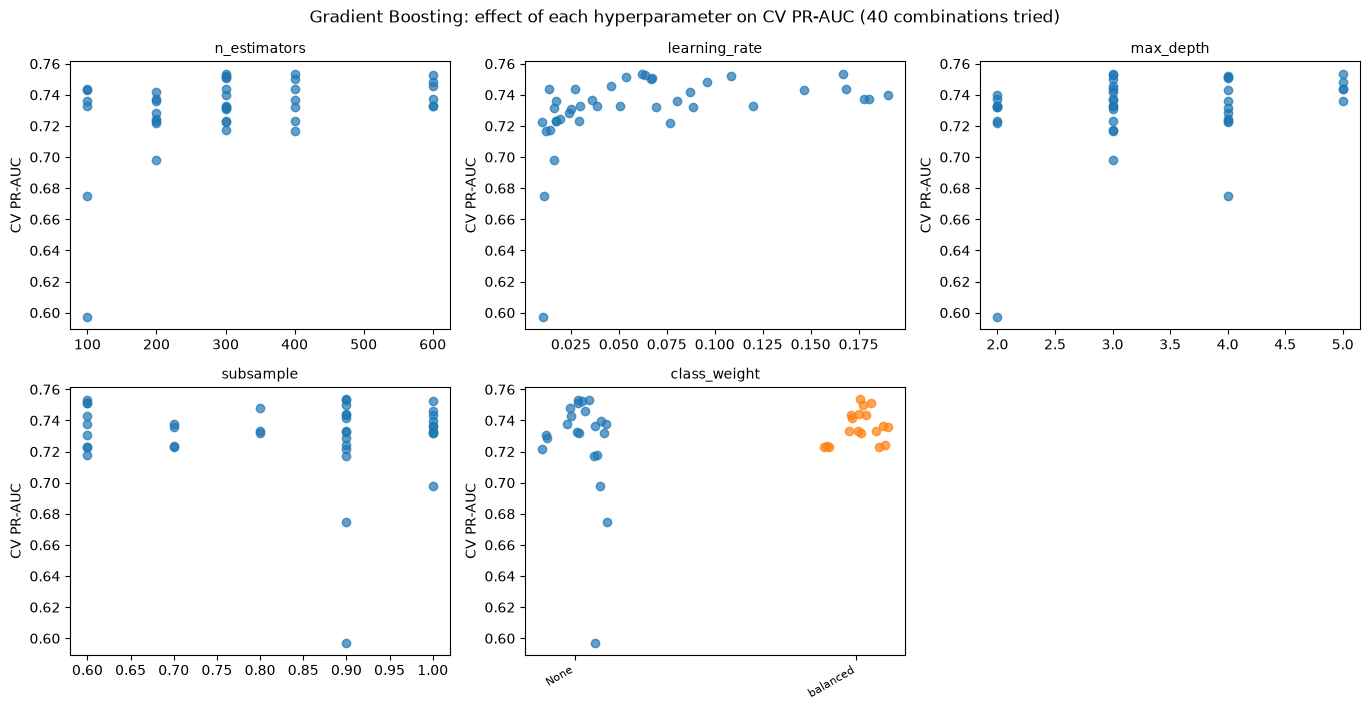

In [10]:
tc.plot_param_effects(MODEL_NAME, search)

## 5. Save results and the tuned model
Writes the CSV / JSON files read by `06e` and saves the tuned model (a plain scikit-learn model) to `models/tuned/`. **No test data is used.**

In [11]:
tc.save_search(MODEL_NAME, search)

{'cv_results': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_gradient_boosting_cv_results.csv',
 'best_folds': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_gradient_boosting_best_folds.csv',
 'summary': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_gradient_boosting_summary.csv',
 'best_json': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\docs\\deliverables_eval2\\tuning\\tuning_gradient_boosting_best.json',
 'model': 'C:\\Users\\LOQ\\OneDrive\\Documents\\GitHub\\routeright-reassignment-predictor\\models\\tuned\\gradient_boosting_tuned.pkl'}

## 6. Interpretation — feature importance

Best settings: {'class_weight': 'balanced', 'learning_rate': 0.16684619386293467, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.9}


,importance
assignment_group_20,0.1018
opened_month,0.0802
u_symptom_534,0.0667
assignment_group_64,0.0615
assignment_group_70,0.0434
opened_by_Other,0.0392
opened_hour,0.0314
assignment_group_9,0.0295
u_symptom_532,0.0222
u_symptom_Other,0.0198


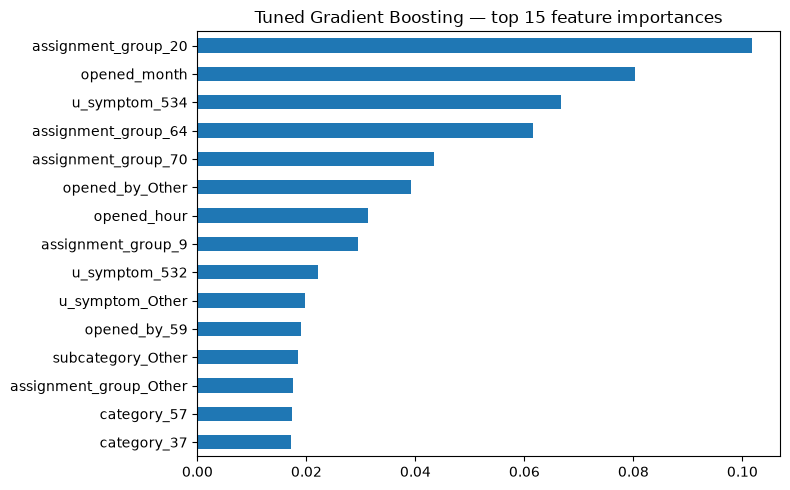

In [12]:
gb = search.best_estimator_
print("Best settings:", tc.clean_params(search.best_params_))
imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
display(imp.round(4).to_frame("importance"))
imp.iloc[::-1].plot.barh(figsize=(8, 5), title="Tuned Gradient Boosting — top 15 feature importances")
plt.tight_layout(); plt.savefig(tc.TUNE_DIR / "tuning_gradient_boosting_importance.png", dpi=130); plt.show()

## 7. Observations
*(to be written after the run)*